# 03 — Frequency Domain Analysis (FFT)
### Phần thứ hai của mục 0.2 — Phổ FFT, quan sát đỉnh dịch chuyển theo tải

**Mục đích**: vẽ FFT của cùng một loại lỗi qua các mức tải khác nhau, quan
sát các đỉnh phổ **dịch chuyển vị trí** trên trục Hz khi tải thay đổi (vì
tốc độ quay động cơ thay đổi theo tải) — đây chính là lý do cần Order-domain
Normalization ở notebook 04.

Notebook này cũng dùng để **chọn dải bandpass cho Square-Law Demodulation**
ở notebook 05 — quan sát vùng tần số có biên độ nổi bật nhất trên file có
lỗi rõ ràng.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from common import io_utils, pipeline, dsp, config as cfg
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = True
REAL_DATA_ROOT = Path("../../data/raw")            # <-- de_tai_nckh/data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

> ⚠️ **Lưu ý dữ liệu giả lập**: khi `USE_SYNTHETIC_DATA = True`, mọi tín hiệu
> trong notebook này là **giả lập** (nhiễu + xung điều biên mô phỏng), chỉ để
> kiểm tra code chạy đúng và xem trước hình dạng đầu ra. **Không dùng số liệu
> giả lập này làm kết quả báo cáo chính thức.** Khi có dữ liệu CWRU thật, đổi
> `USE_SYNTHETIC_DATA = False` ở cell CẤU HÌNH và chạy lại toàn bộ notebook.

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 40


,file_path,load_hp,label,fault_diameter_mils,or_position,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,_data/synthetic_cwru/0hp/B_007.mat,0,B,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
1,_data/synthetic_cwru/0hp/B_014.mat,0,B,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
2,_data/synthetic_cwru/0hp/B_021.mat,0,B,21.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
3,_data/synthetic_cwru/0hp/IR_007.mat,0,IR,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
4,_data/synthetic_cwru/0hp/IR_014.mat,0,IR,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False


## FFT của cùng 1 loại lỗi qua các mức tải (trục Hz)

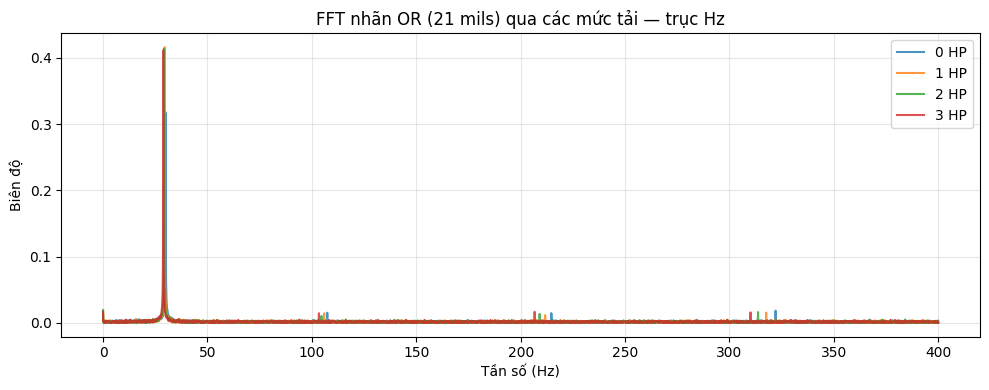

In [5]:
FAULT_LABEL = "OR"       # đổi nhãn muốn xem: "IR", "OR", "B"
DIAMETER_MILS = 21       # đường kính lỗi muốn xem (7/14/21 — trong phạm vi SKF)
FREQ_MAX_HZ = 400

fig, ax = plt.subplots(figsize=(10, 4))
signals_by_load = {}
for load_hp in sorted(manifest["load_hp"].dropna().unique()):
    load_hp = int(load_hp)
    try:
        fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp, diameter_mils=DIAMETER_MILS)
    except ValueError:
        continue
    x = io_utils.load_de_signal(Path(fp))
    signals_by_load[load_hp] = x
    freqs, mag = dsp.compute_fft(x, fs=12000)
    mask = freqs <= FREQ_MAX_HZ
    ax.plot(freqs[mask], mag[mask], label=f"{load_hp} HP", alpha=0.8)

ax.set_xlabel("Tần số (Hz)")
ax.set_ylabel("Biên độ")
ax.set_title(f"FFT nhãn {FAULT_LABEL} ({DIAMETER_MILS} mils) qua các mức tải — trục Hz")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_fft_hz_across_loads.png", dpi=150)
plt.show()

## Đối chiếu với tần số lỗi lý thuyết

So vị trí đỉnh phổ quan sát được ở trên với BPFO/BPFI/BSF lý thuyết
(công thức SKF 6205, `common/config.py`) tại từng mức tải.

In [6]:
rows = []
for load_hp in sorted(signals_by_load.keys()):
    rpm = cfg.NOMINAL_RPM_BY_LOAD.get(load_hp)
    if rpm is None:
        continue
    freqs = cfg.bearing_fault_frequencies(rpm)
    rows.append({"load_hp": load_hp, "rpm_danh_dinh": rpm, **freqs})

theoretical_df = pd.DataFrame(rows).round(2)
theoretical_df.to_csv(TABLES_DIR / "03_theoretical_fault_freq_by_load.csv", index=False)
theoretical_df

,load_hp,rpm_danh_dinh,f_rot,BPFO,BPFI,BSF,FTF
0,0,1797,29.95,107.36,162.19,70.58,11.93
1,1,1772,29.53,105.87,159.93,69.60,11.76
2,2,1750,29.17,104.56,157.94,68.74,11.62
3,3,1730,28.83,103.36,156.14,67.95,11.48


## Quan sát

- Đỉnh phổ có dịch chuyển theo tải như bảng lý thuyết dự đoán không?
- Ghi lại dải tần số có biên độ nổi bật nhất (thường quanh vùng cộng hưởng
  cơ khí) — dùng làm điểm khởi đầu để chọn `band` cho Square-Law
  Demodulation ở notebook 05.

Hình đã lưu tại `outputs/figures/03_fft_hz_across_loads.png`.